

## Objetivo:
Modelo de simulação Monte Carlo para avaliar quanto tempo uma pessoa levaria para atingir uma meta financeira (no caso, R$ 300.000) considerando renda, despesas fixas, variáveis e imprevistos.


Resumo dos Cenários:

              Prob. Sucesso (até 240m)  Mediana Meses  Média Meses  \
Baixa | Baixo                    89.7%          145.0   152.699799   
Baixa | Médio                    94.2%          124.0   131.814610   
Baixa | Alto                     96.4%          100.0   107.237039   
Média | Baixo                    84.7%          159.0   165.759329   
Média | Médio                    91.4%          134.0   141.492449   
Média | Alto                     94.4%          107.0   115.492265   
Alta | Baixo                     60.6%          195.0   197.150775   
Alta | Médio                     79.1%          165.0   171.567527   
Alta | Alto                      88.9%          129.0   137.599595   

              Prob ≤120m (10 anos) Prob ≤180m (15 anos) Prob ≤240m (20 anos)  
Baixa | Baixo                 0.6%                76.3%                89.7%  
Baixa | Médio                40.7%                88.3%                94.2%  
Baixa | Alto                 79.7%      

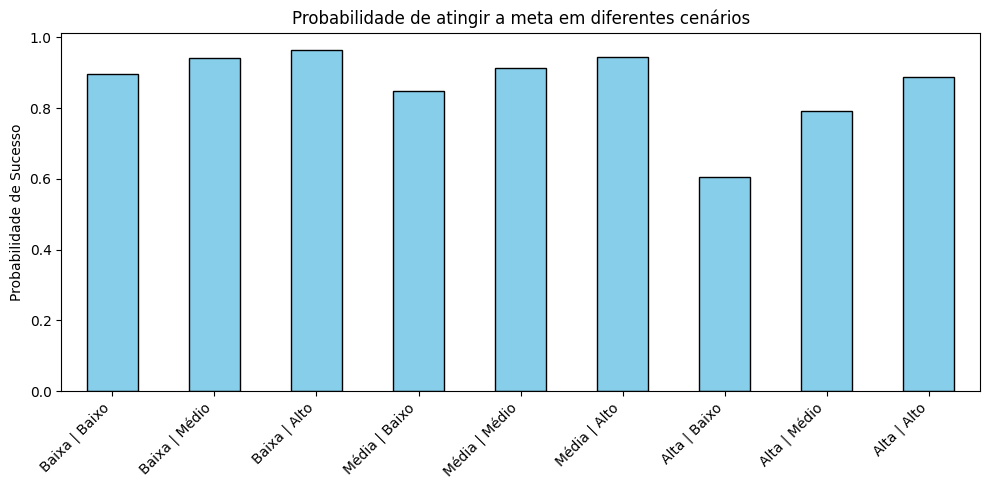

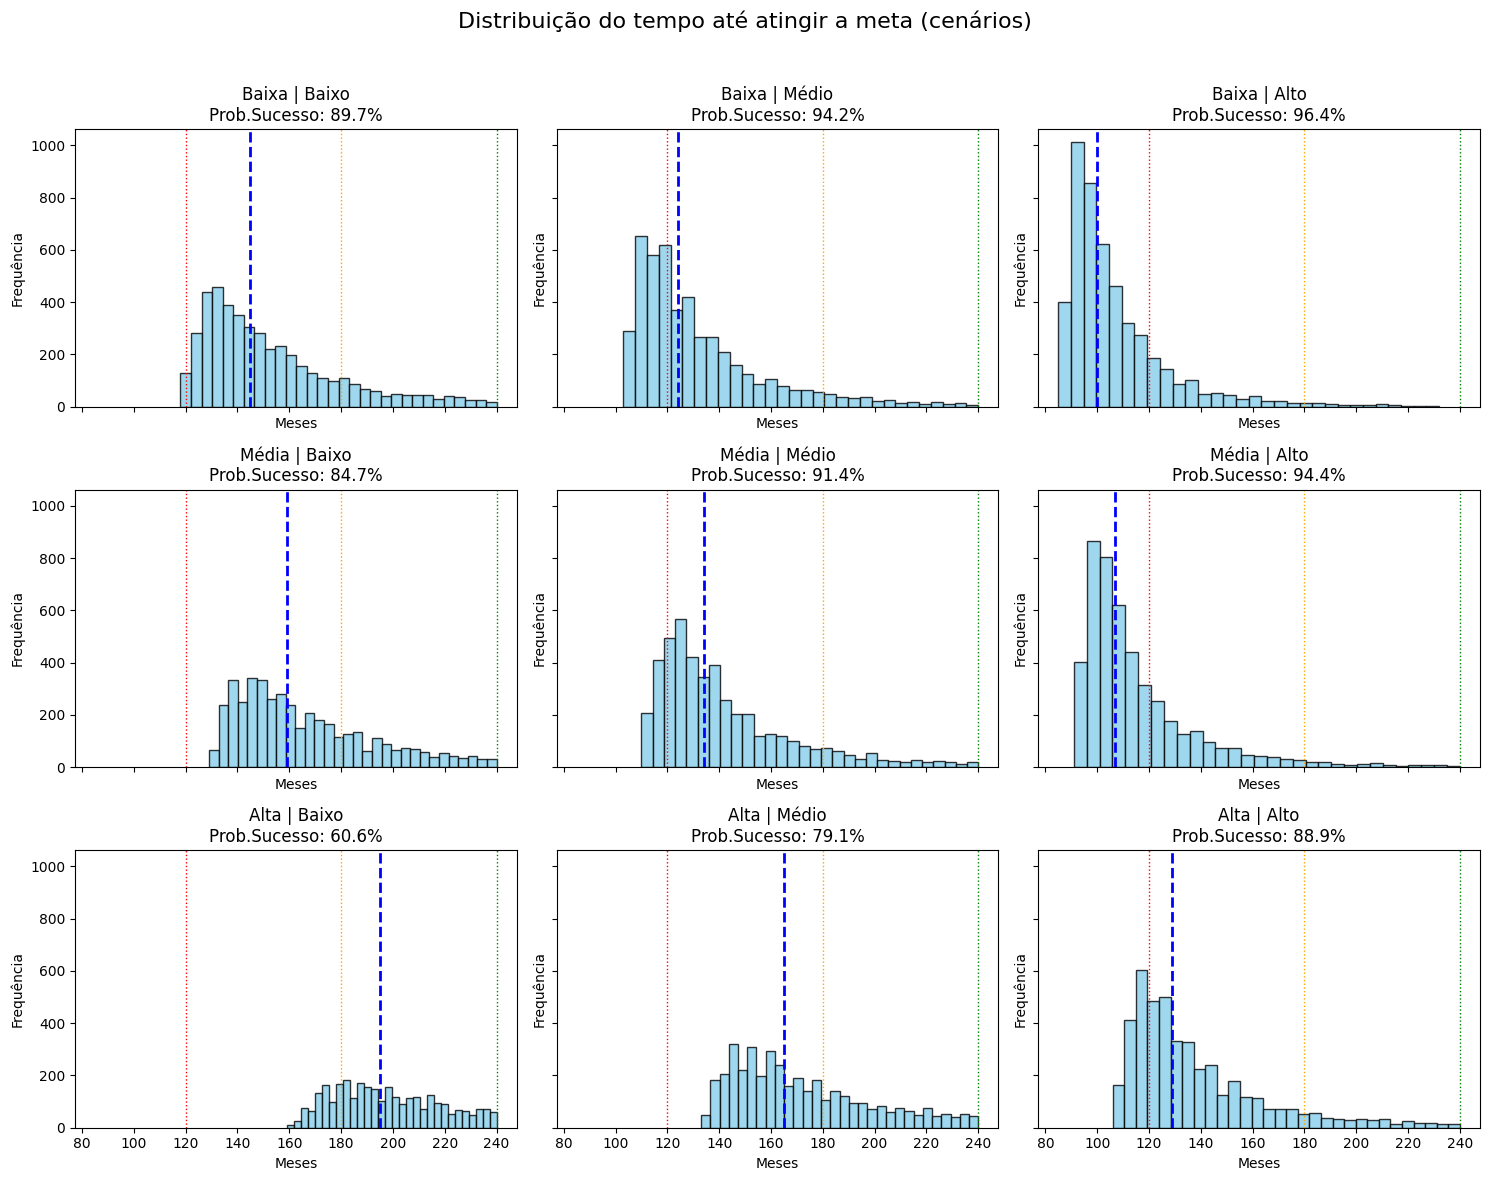

In [ ]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- FUNÇÕES DA SIMULAÇÃO ---
def simular_poupanca(alvo,
                     renda,
                     despesas_fixas,
                     despesas_variaveis=0.0,
                     poisson_lambda=0.5,
                     lognorm_media=6.0,
                     lognorm_sigma=1.0,
                     permitir_saldo_negativo=True,
                     taxa_juros_mensal=0.0,
                     taxa_juros_divida_mensal=0.0,
                     meses_max=1200,
                     rng=None):
    if rng is None:
        rng = np.random.default_rng()

    poupanca_acumulada = 0.0
    for mes in range(1, meses_max + 1):
        n_eventos = rng.poisson(poisson_lambda)
        gasto_inesperado = 0.0
        if n_eventos > 0:
            gasto_inesperado = rng.lognormal(mean=lognorm_media,
                                             sigma=lognorm_sigma,
                                             size=n_eventos).sum()
        poupanca_possivel = renda - despesas_fixas - despesas_variaveis - gasto_inesperado
        if not permitir_saldo_negativo:
            poupanca_mes = max(0.0, poupanca_possivel)
        else:
            poupanca_mes = poupanca_possivel
        if poupanca_acumulada > 0 and taxa_juros_mensal != 0:
            poupanca_acumulada *= (1.0 + taxa_juros_mensal)
        if poupanca_acumulada < 0 and taxa_juros_divida_mensal != 0:
            poupanca_acumulada *= (1.0 + taxa_juros_divida_mensal)
        poupanca_acumulada += poupanca_mes
        if poupanca_acumulada >= alvo:
            return mes, poupanca_acumulada
    return None, poupanca_acumulada


def rodar_varias_simulacoes(n_simulacoes,
                            alvo,
                            renda,
                            despesas_fixas,
                            despesas_variaveis=0.0,
                            permitir_saldo_negativo=True,
                            taxa_juros_mensal=0.0,
                            taxa_juros_divida_mensal=0.0,
                            meses_max=1200,
                            seed=None):
    rng = np.random.default_rng(seed)
    resultados = []
    for i in range(n_simulacoes):
        poisson_lambda = rng.uniform(0.3, 1.2)
        lognorm_media = rng.normal(6.0, 0.5)
        lognorm_sigma = rng.uniform(0.8, 1.5)
        meses, saldo_final = simular_poupanca(alvo,
                                              renda,
                                              despesas_fixas,
                                              despesas_variaveis,
                                              poisson_lambda,
                                              lognorm_media,
                                              lognorm_sigma,
                                              permitir_saldo_negativo,
                                              taxa_juros_mensal,
                                              taxa_juros_divida_mensal,
                                              meses_max,
                                              rng=rng)
        resultados.append((meses, saldo_final))
    return pd.DataFrame(resultados, columns=["meses", "saldo_final"])


# --- PARÂMETROS ---
ALVO = 300000.0
RENDA = 3800.0
DESPESAS_FIXAS = 1200.0
N_SIMULACOES = 5000
MESES_MAX = 240

cenarios_despesas = {"Baixa": 300, "Média": 500, "Alta": 950}
cenarios_juros = {"Baixo": 0.002, "Médio": 0.005, "Alto": 0.01}

# --- RODANDO CENÁRIOS ---
resultados_cenarios = {}
dados_cenarios = {}

for nome_desp, desp_var in cenarios_despesas.items():
    for nome_juros, juros in cenarios_juros.items():
        chave = f"{nome_desp} | {nome_juros}"
        df = rodar_varias_simulacoes(
            n_simulacoes=N_SIMULACOES,
            alvo=ALVO,
            renda=RENDA,
            despesas_fixas=DESPESAS_FIXAS,
            despesas_variaveis=desp_var,
            permitir_saldo_negativo=True,
            taxa_juros_mensal=juros,
            taxa_juros_divida_mensal=0.05,
            meses_max=MESES_MAX,
            seed=42
        )

        meses_numeric = df["meses"].copy().fillna(np.inf)
        proporcao_sucesso = (df["meses"].notna().sum()) / len(df)
        meses_sucesso = df["meses"].dropna().astype(int)

        resultados_cenarios[chave] = {
            "Prob. Sucesso (até 240m)": proporcao_sucesso,
            "Mediana Meses": meses_sucesso.median() if not meses_sucesso.empty else np.nan,
            "Média Meses": meses_sucesso.mean() if not meses_sucesso.empty else np.nan,
            "Prob ≤120m (10 anos)": (meses_numeric <= 120).mean(),
            "Prob ≤180m (15 anos)": (meses_numeric <= 180).mean(),
            "Prob ≤240m (20 anos)": (meses_numeric <= 240).mean()
        }
        dados_cenarios[chave] = df

# --- TABELA RESUMO ---
df_resultados = pd.DataFrame(resultados_cenarios).T

# Converter colunas de probabilidade para percentuais
colunas_prob = [
    "Prob. Sucesso (até 240m)",
    "Prob ≤120m (10 anos)",
    "Prob ≤180m (15 anos)",
    "Prob ≤240m (20 anos)"
]
for col in colunas_prob:
    if col in df_resultados.columns:
        df_resultados[col] = (df_resultados[col] * 100).round(1).astype(str) + "%"

print("Resumo dos Cenários:\n")
print(df_resultados)


# --- GRÁFICO DE PROBABILIDADE DE SUCESSO ---
df_resultados_plot = pd.DataFrame(resultados_cenarios).T
df_resultados_plot["Prob. Sucesso (até 240m)"].plot(
    kind="bar", figsize=(10,5), color="skyblue", edgecolor="black"
)
plt.title("Probabilidade de atingir a meta em diferentes cenários")
plt.ylabel("Probabilidade de Sucesso")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# --- HISTOGRAMAS DETALHADOS ---
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (chave, df) in enumerate(dados_cenarios.items()):
    meses_sucesso = df["meses"].dropna().astype(int)
    ax = axes[idx]
    counts, bins, patches = ax.hist(meses_sucesso, bins=30, alpha=0.8, color="skyblue", edgecolor="black")

    # linhas verticais de referência
    ax.axvline(120, color='red', linestyle=':', linewidth=1, label="10 anos")
    ax.axvline(180, color='orange', linestyle=':', linewidth=1, label="15 anos")
    ax.axvline(240, color='green', linestyle=':', linewidth=1, label="20 anos")

    # --- NOVO: linha da mediana ---
    mediana = resultados_cenarios[chave]["Mediana Meses"]
    if not np.isnan(mediana):
        ax.axvline(mediana, color="blue", linestyle="--", linewidth=2, label=f"Mediana: {int(mediana)}m")

    # título do gráfico com probabilidade formatada em %
    prob_sucesso_pct = resultados_cenarios[chave]["Prob. Sucesso (até 240m)"] * 100
    ax.set_title(f"{chave}\nProb.Sucesso: {prob_sucesso_pct:.1f}%")
    ax.set_xlabel("Meses")
    ax.set_ylabel("Frequência")

plt.suptitle("Distribuição do tempo até atingir a meta (cenários)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
